# A decision log is an instrument, and an instrument has a scoring rule

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/decision-log/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/decision-log/demo.ipynb)

**Day 155 of the FDE portfolio.**

A decision log without a prediction attached is a diary: it records what was
chosen and can never say whether choosing it was any good. Attach a probability
and it becomes an instrument - and an instrument has a **scoring rule**, which
is a choice, and which almost nobody makes deliberately.

That choice has a consequence most teams never see. A scoring rule can be
**improper**: the forecast that maximises a person's expected score is not the
forecast they believe. Under an improper rule, telling you the truth costs your
team points. **Three of the six rules here are improper, and two of them are the
ones teams invent for themselves.**

| § | |
|---|---|
| 1 | Half the records cannot be scored at all |
| 2 | Six rules, and which of them are proper - computed, not quoted |
| 3 | The optimal lie, rule by rule |
| 4 | The rule does not measure the winner, it picks one |
| 5 | Perfect calibration, zero skill |
| 6 | Judging a decision by its outcome is wrong 4 times in 10 |
| 7 | How many decisions before the log concludes anything |
| 8 | The record schema, and what each field is load-bearing for |

## 1. Half the records cannot be scored at all

Before any scoring rule matters, the record has to contain something that can
turn out to be **wrong**. Four fields are required: a probability strictly
between 0 and 1, a real resolution date, a named metric, and a threshold.

The corpus below is illustrative - written, not sampled - so the rate is a
property of these 20 records, not a measurement of the world. The **linter** is
the reusable part. Note the pairs: every record is followed by the same decision
written properly.

In [1]:
from __future__ import annotations

import re
from typing import Dict

import numpy as np

RECORDS = [
    # (id, decision, claim, probability, resolve_by, metric, threshold)
    ("D-001", "Migrate the warehouse", "query costs will fall", None, None, None, None),
    ("D-002", "Migrate the warehouse", "median dashboard query latency drops below 4s",
     0.7, "2026-12-01", "p50_query_latency_s", "< 4"),
    ("D-003", "Hire a second analytics engineer", "the team will move faster",
     None, None, None, None),
    ("D-004", "Hire a second analytics engineer", "dbt model lead time falls under 5 days",
     0.55, "2027-02-01", "model_lead_time_days", "< 5"),
    ("D-007", "Ship the pricing change", "revenue will improve", 0.8, None, None, None),
    ("D-008", "Ship the pricing change", "net revenue retention rises by 2pp",
     0.35, "2027-01-31", "nrr_delta_pp", ">= 2"),
    ("D-009", "Rewrite ingestion in Go", "it will be more maintainable",
     None, "2026-10-01", None, None),
    ("D-010", "Rewrite ingestion in Go", "on-call pages from ingestion below 2/month",
     0.5, "2027-03-01", "ingestion_pages_per_month", "< 2"),
    ("D-015", "Roll out the LLM support assistant", "customers will love it",
     0.9, None, None, None),
    ("D-016", "Roll out the LLM support assistant", "deflection rate above 25%",
     0.3, "2027-04-01", "deflection_rate", ">= 0.25"),
]

ISO = re.compile(r"^\d{4}-\d{2}-\d{2}$")


def lint(rec) -> Dict[str, bool]:
    _id, _dec, _claim, prob, by, metric, thresh = rec
    return {
        "has_probability": prob is not None and 0.0 < prob < 1.0,
        "has_resolution_date": by is not None and bool(ISO.match(by)),
        "has_metric": bool(metric),
        "has_threshold": bool(thresh),
    }


def resolvable(rec) -> bool:
    return all(lint(rec).values())


print(f"{'id':<8}{'prob':>6}  {'resolve by':<12}{'metric':<28}scoreable")
print("-" * 74)
for r in RECORDS:
    p = f"{r[3]:.2f}" if r[3] is not None else "-"
    print(f"{r[0]:<8}{p:>6}  {(r[4] or '-'):<12}{(r[5] or '-'):<28}{'yes' if resolvable(r) else 'NO'}")

ok = sum(1 for r in RECORDS if resolvable(r))
print(f"\n{ok} of {len(RECORDS)} scoreable.")
print("'revenue will improve' has a probability of 0.8 and is still unscoreable -")
print("there is no metric, no threshold and no date, so nothing can ever contradict it.")

id        prob  resolve by  metric                      scoreable
--------------------------------------------------------------------------
D-001        -  -           -                           NO
D-002     0.70  2026-12-01  p50_query_latency_s         yes
D-003        -  -           -                           NO
D-004     0.55  2027-02-01  model_lead_time_days        yes
D-007     0.80  -           -                           NO
D-008     0.35  2027-01-31  nrr_delta_pp                yes
D-009        -  2026-10-01  -                           NO
D-010     0.50  2027-03-01  ingestion_pages_per_month   yes
D-015     0.90  -           -                           NO
D-016     0.30  2027-04-01  deflection_rate             yes

5 of 10 scoreable.
'revenue will improve' has a probability of 0.8 and is still unscoreable -
there is no metric, no threshold and no date, so nothing can ever contradict it.


## 2. Six scoring rules - and which are proper

Every rule is written as a **loss**: lower is better, so they sit on one axis.

A rule is **proper** when the report that minimises expected loss is the report
the forecaster actually believes. We do not look that up - we compute it, by
minimising expected loss over 1001 candidate reports for every true belief.

In [2]:
def brier(q, y):      return (q - y) ** 2
def log_loss(q, y):
    q = np.clip(q, 1e-9, 1 - 1e-9)
    return -(y * np.log(q) + (1 - y) * np.log(1 - q))
def spherical(q, y):
    p_obs = np.where(y == 1, q, 1 - q)
    return 1.0 - p_obs / np.sqrt(q ** 2 + (1 - q) ** 2)
def absolute(q, y):   return np.abs(q - y)
def threshold_01(q, y): return ((q >= 0.5).astype(float) != y).astype(float)
def confidence_points(q, y):
    right = np.where(y == 1, q, 1 - q) > 0.5
    return -np.where(right, q, -q)

RULES = {"brier": brier, "log": log_loss, "spherical": spherical,
         "absolute": absolute, "threshold_01": threshold_01,
         "confidence_points": confidence_points}

GRID = np.linspace(0.0, 1.0, 1001)


def expected_loss(fn, p):
    ones, zeros = np.ones_like(GRID), np.zeros_like(GRID)
    return p * fn(GRID, ones) + (1 - p) * fn(GRID, zeros)


def optimal_report(fn, p):
    return float(GRID[int(np.argmin(expected_loss(fn, p)))])


beliefs = np.round(np.linspace(0.01, 0.99, 99), 2)
print(f"{'rule':<19}{'proper':<9}{'worst gap':>11}{'beliefs misreported':>22}")
print("-" * 62)
PROPER = {}
for name, fn in RULES.items():
    gaps = [abs(optimal_report(fn, float(p)) - p) for p in beliefs]
    bad = sum(1 for g in gaps if g > 0.005)
    PROPER[name] = bad == 0
    print(f"{name:<19}{str(bad == 0):<9}{max(gaps):>11.3f}{bad:>16} of 99")

rule               proper     worst gap   beliefs misreported
--------------------------------------------------------------
brier              True           0.000               0 of 99
log                True           0.000               0 of 99
spherical          True           0.000               0 of 99
absolute           False          0.500              99 of 99
threshold_01       False          0.500              99 of 99
confidence_points  False          0.500              99 of 99


## 3. The optimal lie

Read a row as: *"I believe 55%, so I will report ___, because that scores best."*

In [3]:
show = (0.55, 0.6, 0.7, 0.8, 0.9)
print(f"{'rule':<19}" + "".join(f"{'p=' + str(p):>10}" for p in show))
print("-" * 70)
for name, fn in RULES.items():
    print(f"{name:<19}" + "".join(f"{optimal_report(fn, p):>10.2f}" for p in show))

print("\n`absolute` and `confidence_points` return 1.00 for every belief above a coin flip.")
print("A forecaster who believes 55% and says 55% scores WORSE than one who claims certainty.\n")

# threshold_01 has no single optimum - it has a plateau.
e = expected_loss(threshold_01, 0.7)
tied = GRID[e <= e.min() + 1e-12]
print(f"threshold_01 at p=0.70: every report in [{tied.min():.2f}, {tied.max():.2f}] "
      f"scores identically - a plateau {tied.max() - tied.min():.2f} wide.")
print("It does not punish confidence. It cannot SEE confidence.")

rule                   p=0.55     p=0.6     p=0.7     p=0.8     p=0.9
----------------------------------------------------------------------
brier                    0.55      0.60      0.70      0.80      0.90
log                      0.55      0.60      0.70      0.80      0.90
spherical                0.55      0.60      0.70      0.80      0.90
absolute                 1.00      1.00      1.00      1.00      1.00
threshold_01             0.50      0.50      0.50      0.50      0.50
confidence_points        1.00      1.00      1.00      1.00      1.00

`absolute` and `confidence_points` return 1.00 for every belief above a coin flip.
A forecaster who believes 55% and says 55% scores WORSE than one who claims certainty.

threshold_01 at p=0.70: every report in [0.50, 1.00] scores identically - a plateau 0.50 wide.
It does not punish confidence. It cannot SEE confidence.


## 4. The rule does not measure the winner, it picks one

Six forecasters, all fully specified, forecasting the same 4,000 events. The
only thing that changes between columns is the scoring rule.

In [4]:
RNG_SEED = 20260825


def logit(p): return np.log(np.clip(p, 1e-9, 1 - 1e-9) / (1 - np.clip(p, 1e-9, 1 - 1e-9)))
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))


# name -> (bias, sharpen, noise, blind)
FORECASTERS = {
    "calibrated":     (0.0, 1.00, 0.0, False),
    "overconfident":  (0.0, 2.20, 0.0, False),
    "underconfident": (0.0, 0.45, 0.0, False),
    "optimist":       (0.9, 1.00, 0.0, False),
    "noisy_expert":   (0.0, 1.00, 1.1, False),
    "base_rate":      (0.0, 1.00, 0.0, True),
}

rng = np.random.default_rng(RNG_SEED)
n = 4000
truth = rng.beta(2.0, 2.5, size=n)
outcomes = (rng.random(n) < truth).astype(float)
base = float(truth.mean())

reports = {}
for name, (bias, sharpen, noise, blind) in FORECASTERS.items():
    if blind:
        q = np.full(n, base)
    else:
        z = logit(truth) * sharpen + bias
        if noise:
            z = z + rng.normal(0.0, noise, size=n)
        q = sigmoid(z)
    reports[name] = np.clip(q, 0.001, 0.999)

table = {f: {r: float(np.mean(fn(reports[f], outcomes))) for r, fn in RULES.items()}
         for f in FORECASTERS}

print(f"{'forecaster':<16}" + "".join(f"{r[:10]:>12}" for r in RULES))
print("-" * 88)
for f in FORECASTERS:
    print(f"{f:<16}" + "".join(f"{table[f][r]:>12.4f}" for r in RULES))

print("\nWinner under each rule:")
for r in RULES:
    order = sorted(FORECASTERS, key=lambda f: table[f][r])
    tag = "proper" if PROPER[r] else "IMPROPER"
    print(f"    {r:<19} ({tag:<8}) 1st: {order[0]:<15} last: {order[-1]}")

forecaster             brier         log   spherical    absolute  threshold_  confidence
----------------------------------------------------------------------------------------
calibrated            0.2020      0.5878      0.2306      0.4043      0.3162     -0.1499
overconfident         0.2177      0.6642      0.2441      0.3558      0.3162     -0.1364
underconfident        0.2130      0.6158      0.2431      0.4495      0.3162     -0.1650
optimist              0.2372      0.6701      0.2739      0.4287      0.3915     -0.1218
noisy_expert          0.2403      0.6950      0.2739      0.4134      0.3743     -0.0906
base_rate             0.2471      0.6872      0.2887      0.4942      0.4457     -0.0484

Winner under each rule:
    brier               (proper  ) 1st: calibrated      last: base_rate
    log                 (proper  ) 1st: calibrated      last: noisy_expert
    spherical           (proper  ) 1st: calibrated      last: base_rate
    absolute            (IMPROPER) 1st: over

Two things worth stopping on.

**`absolute` - "average error", the rule that ends up in a spreadsheet - crowns
the OVERCONFIDENT forecaster.** A team scoring its decision log that way will
promote whoever is most often confidently wrong. `confidence_points`, the
in-house prediction game, crowns the *underconfident* one. Two homebrew rules,
two opposite wrong answers.

**Log loss puts `noisy_expert` last - below the forecaster that knows nothing.**
That one is not a homebrew mistake; log loss is proper. It is unbounded, so a
handful of confident misses dominate the mean. Proper is not the whole
specification.

In [5]:
q = reports["noisy_expert"]
misses = int(((q > 0.9) & (outcomes == 0)).sum() + ((q < 0.1) & (outcomes == 1)).sum())
qb = reports["base_rate"]
print(f"{'':<16}{'brier':>10}{'log':>10}")
print("-" * 38)
for f in ("noisy_expert", "base_rate"):
    print(f"{f:<16}{table[f]['brier']:>10.4f}{table[f]['log']:>10.4f}")
print(f"\nnoisy_expert makes {misses} confident misses in {n} events.")
print(f"base_rate makes {int(((qb > 0.9) | (qb < 0.1)).sum())} - it never commits, so it is never caught.")
print("Better by Brier, worst of all six by log loss.")

                     brier       log
--------------------------------------
noisy_expert        0.2403    0.6950
base_rate           0.2471    0.6872

noisy_expert makes 141 confident misses in 4000 events.
base_rate makes 0 - it never commits, so it is never caught.
Better by Brier, worst of all six by log loss.


## 5. Perfect calibration, zero skill

Murphy's decomposition: **Brier = reliability - resolution + uncertainty.**

*Reliability* is "when you said 70%, did it happen 70% of the time" - what
everybody means by calibration, and the only part a recalibration step can fix.
*Resolution* is "did you separate the cases at all", and it carries the
information.

A forecaster can be perfectly reliable and completely useless.

In [6]:
def murphy(q, y, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(q, edges[1:-1]), 0, bins - 1)
    ybar, N = float(y.mean()), len(y)
    rel = res = 0.0
    for k in range(bins):
        m = idx == k
        if m.sum() == 0:
            continue
        rel += m.sum() * (q[m].mean() - y[m].mean()) ** 2
        res += m.sum() * (y[m].mean() - ybar) ** 2
    return {"brier": float(np.mean((q - y) ** 2)), "reliability": rel / N,
            "resolution": res / N, "uncertainty": ybar * (1 - ybar)}


d = {f: murphy(reports[f], outcomes) for f in FORECASTERS}
print(f"{'forecaster':<16}{'brier':>9}{'reliability':>13}{'resolution':>12}{'uncertainty':>13}")
print("-" * 64)
for f in sorted(FORECASTERS, key=lambda x: d[x]["brier"]):
    m = d[f]
    print(f"{f:<16}{m['brier']:>9.4f}{m['reliability']:>13.4f}"
          f"{m['resolution']:>12.4f}{m['uncertainty']:>13.4f}")

print(f"\nbase_rate: reliability {d['base_rate']['reliability']:.4f} - PERFECT calibration.")
print(f"           resolution  {d['base_rate']['resolution']:.4f} - and the worst Brier of the six.")
print("\n'Improve your calibration' would give this forecaster full marks.")

flips = [(a, b) for a in d for b in d
         if a != b and d[a]["reliability"] < d[b]["reliability"] and d[a]["brier"] > d[b]["brier"]]
print(f"\n{len(flips)} ordered pairs where the MORE reliable forecaster scores WORSE overall.")
for a, b in flips[:4]:
    print(f"    {a:<15} better calibrated than {b:<15} and worse overall")

forecaster          brier  reliability  resolution  uncertainty
----------------------------------------------------------------
calibrated         0.2020       0.0001      0.0441       0.2471
underconfident     0.2130       0.0100      0.0415       0.2471
overconfident      0.2177       0.0153      0.0439       0.2471
optimist           0.2372       0.0352      0.0439       0.2471
noisy_expert       0.2403       0.0168      0.0228       0.2471
base_rate          0.2471       0.0000      0.0000       0.2471

base_rate: reliability 0.0000 - PERFECT calibration.
           resolution  0.0000 - and the worst Brier of the six.

'Improve your calibration' would give this forecaster full marks.

6 ordered pairs where the MORE reliable forecaster scores WORSE overall.
    noisy_expert    better calibrated than optimist        and worse overall
    base_rate       better calibrated than calibrated      and worse overall
    base_rate       better calibrated than overconfident   and worse overa

## 6. Judging a decision by its outcome is wrong 4 times in 10

The outcome is a single noisy draw from a distribution the decision only
*shifted*. Without a recorded probability there is nothing to separate a good
decision that lost from a bad one that lost - and a review of the log will
separate them by outcome, because that is the only thing left in the record.

In [7]:
rng2 = np.random.default_rng(RNG_SEED + 2)
N = 200
p = rng2.uniform(0.25, 0.75, size=N)   # win probability, symmetric payoff
good = p > 0.5                          # positive expected value
won = rng2.random(N) < p
wrong = won != good                     # outcome-based verdict vs the truth

print(f"{N} decisions, some genuinely good, some genuinely bad.")
print("Reviewed purely on how they turned out:\n")
print(f"    truly good decisions        {int(good.sum()):>4}")
print(f"    verdicts that are WRONG     {int(wrong.sum()):>4}   ({wrong.mean():.1%})")
print(f"      good decisions punished   {int((good & ~won).sum()):>4}")
print(f"      bad decisions rewarded    {int((~good & won).sum()):>4}")

200 decisions, some genuinely good, some genuinely bad.
Reviewed purely on how they turned out:

    truly good decisions          98
    verdicts that are WRONG       83   (41.5%)
      good decisions punished     44
      bad decisions rewarded      39


## 7. How many decisions before the log concludes anything?

Paired sample size to separate two forecasters by Brier score at 80% power. This
is the number that decides whether ranking people by their decision log is even
a coherent activity.

In [8]:
from scipy import stats

names = list(FORECASTERS)
need = {}
for i, a in enumerate(names):
    for b in names[i + 1:]:
        diff = brier(reports[a], outcomes) - brier(reports[b], outcomes)
        mean, sd = float(diff.mean()), float(diff.std(ddof=1))
        z = stats.norm.ppf(0.975) + stats.norm.ppf(0.8)
        need[(a, b)] = int(np.ceil((z * sd / abs(mean)) ** 2))

print(f"{'A':<17}{'B':<17}{'decisions needed':>18}")
print("-" * 54)
for (a, b), v in sorted(need.items(), key=lambda kv: kv[1]):
    print(f"{a:<17}{b:<17}{v:>18,}")

reach = sum(1 for v in need.values() if v <= 260)
print(f"\nMedian over {len(need)} pairings: {int(np.median(list(need.values()))):,}")
print("One decision a week for five years is 260 records.")
print(f"At that volume, {reach} of {len(need)} comparisons are resolvable.")
print("\nRanking your people is the use this log supports LEAST.")
print("It is still worth keeping - it makes the reasoning retrievable and forces the")
print("claim to be falsifiable at the moment of writing. Both of those pay off at n=1.")

A                B                  decisions needed
------------------------------------------------------
underconfident   base_rate                        65
calibrated       base_rate                       114
calibrated       optimist                        193
calibrated       noisy_expert                    206
underconfident   optimist                        396
calibrated       overconfident                   406
underconfident   noisy_expert                    438
calibrated       underconfident                  461
overconfident    base_rate                       676
overconfident    noisy_expert                    865
overconfident    optimist                      1,104
optimist         base_rate                     4,976
noisy_expert     base_rate                    10,469
overconfident    underconfident               13,304
optimist         noisy_expert                 53,520

Median over 15 pairings: 461
One decision a week for five years is 260 records.
At that volume, 

## The picture

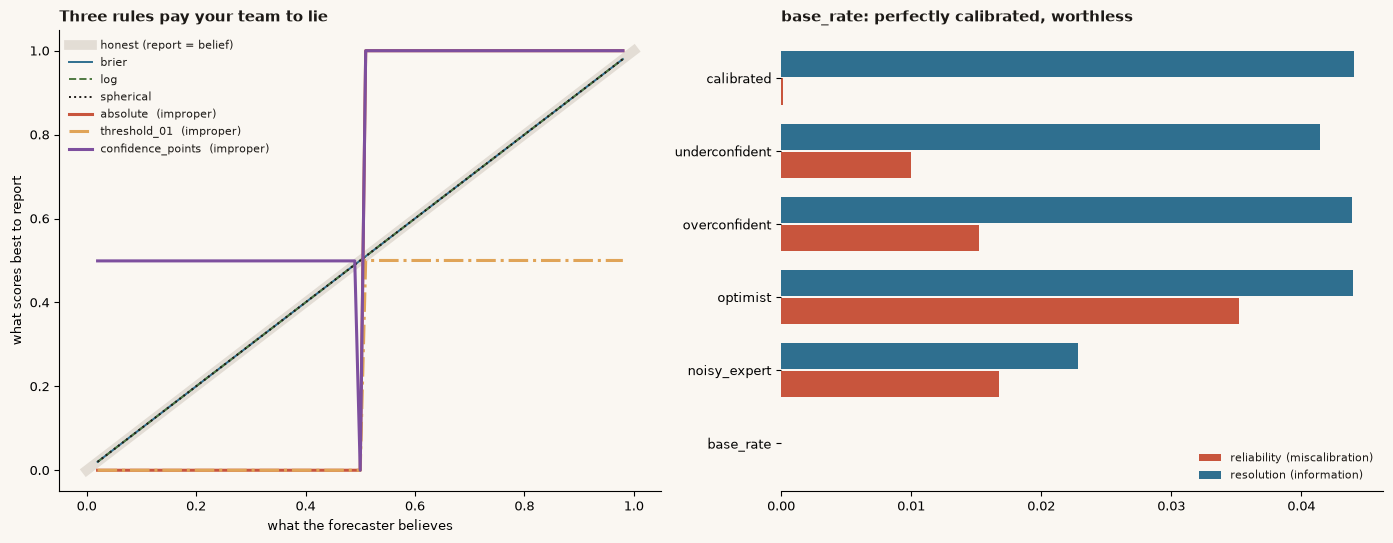

In [9]:
import matplotlib.pyplot as plt

INK, GRIDC, PAPER = "#1d1a17", "#e3ddd5", "#faf7f2"
ACCENT, COOL, WARM, GREEN = "#c8553d", "#2f6f8f", "#e0a458", "#4f7942"
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "text.color": INK, "font.size": 9})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

bel = np.linspace(0.02, 0.98, 97)
ax1.plot([0, 1], [0, 1], color=GRIDC, lw=7, zorder=0, label="honest (report = belief)")
styles = {"brier": (COOL, "-"), "log": (GREEN, "--"), "spherical": (INK, ":"),
          "absolute": (ACCENT, "-"), "threshold_01": (WARM, "-."),
          "confidence_points": ("#7d4f9e", "-")}
for name, fn in RULES.items():
    ys = [optimal_report(fn, float(b)) for b in bel]
    col, ls = styles[name]
    ax1.plot(bel, ys, color=col, ls=ls, lw=2.2 if not PROPER[name] else 1.4,
             label=f"{name}{'' if PROPER[name] else '  (improper)'}")
ax1.set_xlabel("what the forecaster believes")
ax1.set_ylabel("what scores best to report")
ax1.legend(frameon=False, fontsize=8, loc="upper left")
for s in ("top", "right"):
    ax1.spines[s].set_visible(False)
ax1.set_title("Three rules pay your team to lie", loc="left", fontweight="bold")

order = sorted(FORECASTERS, key=lambda f: d[f]["brier"])
y = np.arange(len(order))
ax2.barh(y + 0.19, [d[f]["reliability"] for f in order], height=0.36,
         color=ACCENT, label="reliability (miscalibration)")
ax2.barh(y - 0.19, [d[f]["resolution"] for f in order], height=0.36,
         color=COOL, label="resolution (information)")
ax2.set_yticks(y)
ax2.set_yticklabels(order)
ax2.invert_yaxis()
ax2.legend(frameon=False, fontsize=8, loc="lower right")
for s in ("top", "right", "left"):
    ax2.spines[s].set_visible(False)
ax2.set_title("base_rate: perfectly calibrated, worthless", loc="left", fontweight="bold")

fig.tight_layout()
fig.savefig("notebook_decision.png", dpi=140, facecolor=PAPER)
plt.show()

## 8. Try your own

Paste your team's real forecasts and outcomes. The two questions worth asking of
your own log: which rule are you implicitly using, and could you tell your best
forecaster from your worst one if you tried?

In [10]:
# MY_FORECASTS = [0.9, 0.7, 0.6, 0.8, 0.95, 0.5, 0.3, 0.75]
# MY_OUTCOMES  = [1,   1,   0,   1,   0,    1,   0,   1  ]
#
# q = np.array(MY_FORECASTS, dtype=float)
# y = np.array(MY_OUTCOMES, dtype=float)
#
# print("your scores, by rule:")
# for name, fn in RULES.items():
#     tag = "proper" if PROPER[name] else "IMPROPER - do not use"
#     print(f"  {name:<19} {float(np.mean(fn(q, y))):>9.4f}   {tag}")
#
# m = murphy(q, y, bins=4)
# print(f"\n  brier {m['brier']:.4f} = reliability {m['reliability']:.4f}"
#       f" - resolution {m['resolution']:.4f} + uncertainty {m['uncertainty']:.4f}")
# if m["resolution"] < 0.01:
#     print("  Resolution near zero: these forecasts barely separate the cases.")
#     print("  Recalibration will not help - there is nothing to recalibrate.")

## What to take away

1. **A record without a probability, metric, threshold and date cannot be scored
   - ever.** Lint at write time, not at review time.
2. **Pick the scoring rule deliberately, and pick a proper one.** Brier if humans
   read the number. Log loss if a confident miss is genuinely catastrophic, and
   knowing it will rank a noisy expert below someone who says nothing. Never
   "average error", never a hit rate, never the points game.
3. **Calibration is necessary and not sufficient.** Reliability near zero with
   resolution near zero is a forecaster who reports the base rate and knows
   nothing.
4. **Never review a decision by its outcome alone** - that verdict is wrong about
   40% of the time, and it punishes exactly the people making good bets.
5. **Do not try to rank your team with the log.** It is statistically
   underpowered for that by two orders of magnitude. Its value is that the
   reasoning is retrievable and the claim was falsifiable when it was written.

---

**Full audit:** `python evidence.py` in
[`mini-saas-products/decision-log`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/decision-log) prints all nine sections;
`pytest` asserts every number on this page, including the propriety results
against their closed forms.

**Interactive:** `streamlit run app.py` - paste forecasts, see the rules disagree.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - one small, real tool a day.